In [1]:
!pip install autogluon
!pip install h2o

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━

![](https://h2o.ai/blog/2019/a-deep-dive-into-h2os-automl/_jcr_content/root/section/par/advancedcolumncontrol/columns1/image_0.coreimg.png/1705340041365/h2o-automl.png)
![](https://repository-images.githubusercontent.com/199509705/1989b60f-1195-442c-afd8-e13ea72e8b99)
![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR2xQcwKitRgXfqdi34DYlocPSEXD2G2zZipg&s)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.metrics import mean_squared_log_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
train  = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")

In [4]:
train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [5]:
test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


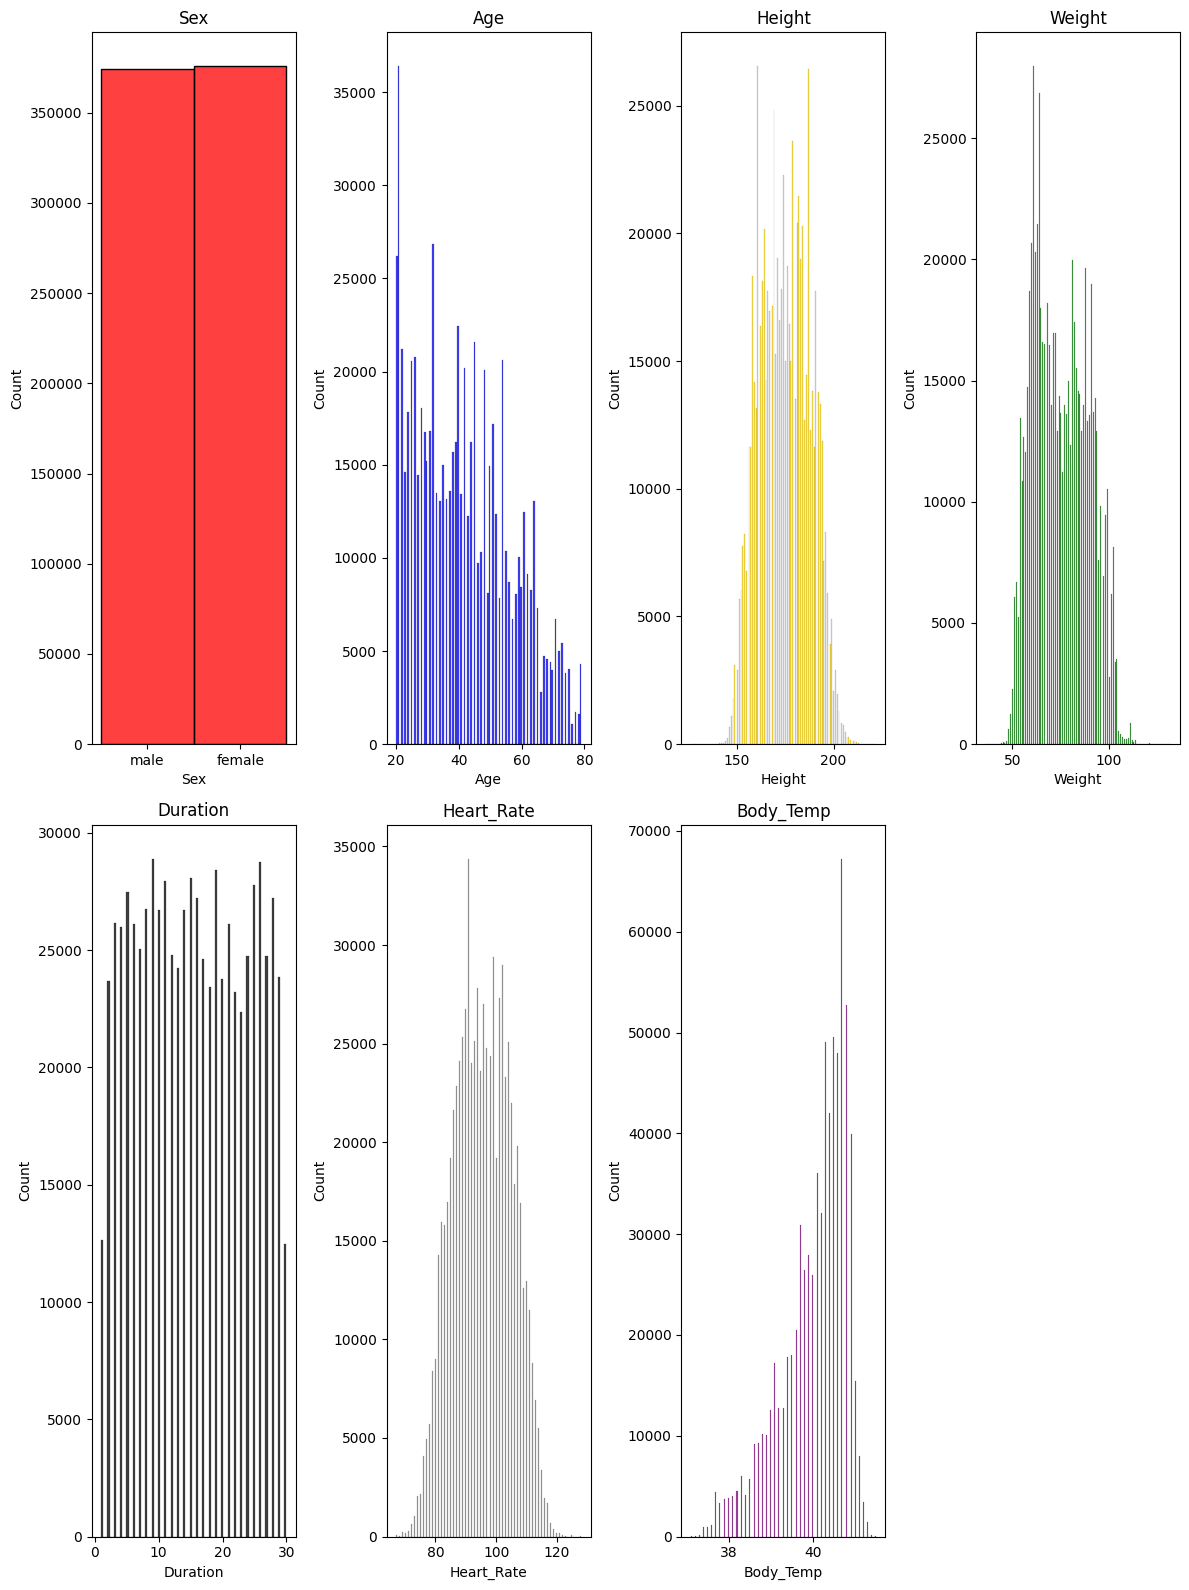

In [6]:
train.drop(columns=['id'], inplace=True)
test.drop(columns=['id'], inplace=True)

cols = ['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
colors = ["red","blue","gold","green","black","gray","purple"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 16))
axes = axes.flatten()

for idx, (col, color) in enumerate(zip(cols, colors)):
    sns.histplot(train[col], color=color, ax=axes[idx])
    axes[idx].set_title(col)
    
for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## MODELING WITH H20

![](https://miro.medium.com/v2/resize:fit:938/1*B6fCnuEPruKNixbUXhYPaw.png)

In [7]:
import h2o
from h2o.automl import H2OAutoML
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.26" 2025-01-21; OpenJDK Runtime Environment (build 11.0.26+4-post-Ubuntu-1ubuntu122.04); OpenJDK 64-Bit Server VM (build 11.0.26+4-post-Ubuntu-1ubuntu122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.11/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpkzlhbk5f
  JVM stdout: /tmp/tmpkzlhbk5f/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpkzlhbk5f/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,1 month and 15 days
H2O_cluster_name:,H2O_from_python_unknownUser_btipfc
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.500 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [8]:
train_data = h2o.H2OFrame(train)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [9]:
test_data = h2o.H2OFrame(test)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [10]:
model = H2OAutoML(max_runtime_secs=60,seed=100,
    sort_metric="RMSLE",distribution="AUTO",
    nfolds=10,exclude_algos=["DeepLearning"],
    verbosity="info")


y = "Calories"
x = [col for col in train.columns if col != y]


model.train(x=x, y=y, training_frame=train_data)

AutoML progress: |
16:25:02.981: Project: AutoML_1_20250512_162502
16:25:02.982: Setting stopping tolerance adaptively based on the training frame: 0.0011547005383792516
16:25:02.983: Build control seed: 100
16:25:02.984: training frame: Frame key: AutoML_1_20250512_162502_training_Key_Frame__upload_91f69d74ab1ae5a73e78b82758ac415a.hex    cols: 8    rows: 750000  chunks: 8    size: 7772114  checksum: 6961179620954357068
16:25:02.985: validation frame: NULL
16:25:02.985: leaderboard frame: NULL
16:25:02.985: blending frame: NULL
16:25:02.985: response column: Calories
16:25:02.986: fold column: null
16:25:02.986: weights column: null
16:25:03.16: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (6g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {GBM : [def_5 (1g, 10w), def_2 (2g, 10w), def_3 (2g, 10w), def_4 (2g, 10w), def_1 (3g, 10w), grid_1 (4g, 60w), lr_annealing (6g, 10w)]}, {DeepLearn

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_1_AutoML_1_20250512_162502


Model Summary: 
    number_of_trees
--  -----------------
    1

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 5744.620671649541
RMSE: 75.79327589997375
MAE: 61.46857610674612
RMSLE: 1.124394856962979
Mean Residual Deviance: 5744.620671649541

ModelMetricsRegression: xgboost
** Reported on cross-validation data. **

MSE: 3415.742336630551
RMSE: 58.444352478494885
MAE: 46.750559480665444
RMSLE: 0.7612196839081357
Mean Residual Deviance: 3415.742336630551

Cross-Validation Metrics Summary: 
                        mean      sd        cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid    cv_6_valid    cv_7_valid    cv_8_valid    cv_9_valid    cv_10_valid
----------------------  --------  --------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  -------------
aic                     nan       0         nan           nan           nan           nan           nan           nan           nan           nan           nan           nan
loglikelihood           nan       0         nan           nan           nan           nan           nan           nan           nan           nan           nan           nan
mae                     46.7506   7.7216    61.567        61.2323       43.1908       43.1052       43.1165       42.9898       43.0022       43.2424       42.9788       43.0808
mean_residual_deviance  3415.74   1219.2    5745.05       5712.66       2855.3        2837.56       2843          2821.52       2827.9        2855.12       2826.07       2833.24
mse                     3415.74   1219.2    5745.05       5712.66       2855.3        2837.56       2843          2821.52       2827.9        2855.12       2826.07       2833.24
r2                      0.122089  0.315651  -0.484137     -0.469417     0.273705      0.271738      0.272867      0.270673      0.272302      0.269175      0.272405      0.271577
residual_deviance       3415.74   1219.2    5745.05       5712.66       2855.3        2837.56       2843          2821.52       2827.9        2855.12       2826.07       2833.24
rmse                    57.752    9.45444   75.7961       75.5822       53.435        53.2687       53.3198       53.1179       53.178        53.4333       53.1608       53.2282
rmsle                   0.735994  0.204851  1.12501       1.12433       0.6389        0.638247      0.638084      0.638773      0.639267      0.639413      0.638711      0.639205

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------
    2025-05-12 16:25:29  26.071 sec  0                  107.699          87.7828         11599
    2025-05-12 16:25:30  27.780 sec  1                  75.7933          61.4686         5744.62

Variable Importances: 
variable    relative_importance    scaled_importance    percentage
----------  ---------------------  -------------------  ------------
Duration    1.63931e+09            1                    0.965709
Heart_Rate  5.05752e+07            0.0308514            0.0297935
Weight      7.26871e+06            0.004434             0.00428195
Sex.female  353753                 0.000215794          0.000208394
Body_Temp   11659.3                7.11229e-06          6.8684e-06

[tips]
Use `model.explain()` to inspect the model.
--
Use `h2o.display.toggle_user_tips()` to switch on/off this section.

In [11]:
model

In [12]:
model.leaderboard

model_id,rmsle,rmse,mse,mae,mean_residual_deviance
XGBoost_1_AutoML_1_20250512_162502,0.76122,58.4444,3415.74,46.7506,3415.74
GBM_1_AutoML_1_20250512_162502,0.966853,56.3474,3175.03,47.7422,3175.03
GLM_1_AutoML_1_20250512_162502,nan,21.9972,483.878,17.107,483.878


In [13]:
model.leader

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_1_AutoML_1_20250512_162502


Model Summary: 
    number_of_trees
--  -----------------
    1

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 5744.620671649541
RMSE: 75.79327589997375
MAE: 61.46857610674612
RMSLE: 1.124394856962979
Mean Residual Deviance: 5744.620671649541

ModelMetricsRegression: xgboost
** Reported on cross-validation data. **

MSE: 3415.742336630551
RMSE: 58.444352478494885
MAE: 46.750559480665444
RMSLE: 0.7612196839081357
Mean Residual Deviance: 3415.742336630551

Cross-Validation Metrics Summary: 
                        mean      sd        cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid    cv_6_valid    cv_7_valid    cv_8_valid    cv_9_valid    cv_10_valid
----------------------  --------  --------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  -------------
aic                     nan       0         nan           nan           nan           nan           nan           nan           nan           nan           nan           nan
loglikelihood           nan       0         nan           nan           nan           nan           nan           nan           nan           nan           nan           nan
mae                     46.7506   7.7216    61.567        61.2323       43.1908       43.1052       43.1165       42.9898       43.0022       43.2424       42.9788       43.0808
mean_residual_deviance  3415.74   1219.2    5745.05       5712.66       2855.3        2837.56       2843          2821.52       2827.9        2855.12       2826.07       2833.24
mse                     3415.74   1219.2    5745.05       5712.66       2855.3        2837.56       2843          2821.52       2827.9        2855.12       2826.07       2833.24
r2                      0.122089  0.315651  -0.484137     -0.469417     0.273705      0.271738      0.272867      0.270673      0.272302      0.269175      0.272405      0.271577
residual_deviance       3415.74   1219.2    5745.05       5712.66       2855.3        2837.56       2843          2821.52       2827.9        2855.12       2826.07       2833.24
rmse                    57.752    9.45444   75.7961       75.5822       53.435        53.2687       53.3198       53.1179       53.178        53.4333       53.1608       53.2282
rmsle                   0.735994  0.204851  1.12501       1.12433       0.6389        0.638247      0.638084      0.638773      0.639267      0.639413      0.638711      0.639205

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------
    2025-05-12 16:25:29  26.071 sec  0                  107.699          87.7828         11599
    2025-05-12 16:25:30  27.780 sec  1                  75.7933          61.4686         5744.62

Variable Importances: 
variable    relative_importance    scaled_importance    percentage
----------  ---------------------  -------------------  ------------
Duration    1.63931e+09            1                    0.965709
Heart_Rate  5.05752e+07            0.0308514            0.0297935
Weight      7.26871e+06            0.004434             0.00428195
Sex.female  353753                 0.000215794          0.000208394
Body_Temp   11659.3                7.11229e-06          6.8684e-06

[tips]
Use `model.explain()` to inspect the model.
--
Use `h2o.display.toggle_user_tips()` to switch on/off this section.

In [14]:
h2o_predictions = model.leader.predict(test_data)
h2o_predictions_df = h2o_predictions.as_data_frame()
h2o_predictions_df

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.11/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,predict
0,8.512025
1,35.592907
2,28.500097
3,38.879822
4,25.019068
...,...
249995,7.732625
249996,3.354518
249997,23.252182
249998,47.063549


## MODELING WITH AUTOGLUON

![](https://avatars.githubusercontent.com/u/92389699?v=4)
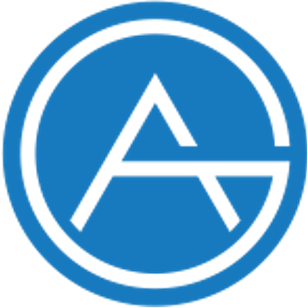
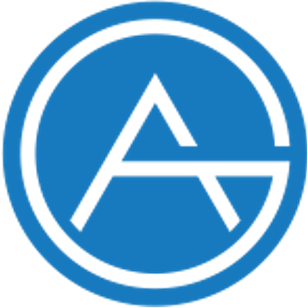

In [15]:
from autogluon.tabular import TabularPredictor

train  = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")

In [16]:
from sklearn.metrics import mean_squared_log_error

label = 'Calories'

predictor = TabularPredictor(label=label, problem_type='regression').fit(train_data=train)

No path specified. Models will be saved in: "AutogluonModels/ag-20250512_162608"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.11.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Nov 10 10:07:59 UTC 2024
CPU Count:          4
Memory Avail:       28.44 GB / 31.35 GB (90.7%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions

[1000]	valid_set's rmse: 3.65863
[2000]	valid_set's rmse: 3.61153
[3000]	valid_set's rmse: 3.60775


	-3.6054	 = Validation score   (-root_mean_squared_error)
	97.17s	 = Training   runtime
	1.27s	 = Validation runtime
Fitting model: LightGBM ...
	-3.5543	 = Validation score   (-root_mean_squared_error)
	16.6s	 = Training   runtime
	0.15s	 = Validation runtime
Fitting model: RandomForestMSE ...
	-3.6856	 = Validation score   (-root_mean_squared_error)
	462.1s	 = Training   runtime
	0.34s	 = Validation runtime
Fitting model: CatBoost ...
	-3.4698	 = Validation score   (-root_mean_squared_error)
	194.44s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: ExtraTreesMSE ...
	-3.6813	 = Validation score   (-root_mean_squared_error)
	182.88s	 = Training   runtime
	0.31s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	-3.5183	 = Validation score   (-root_mean_squared_error)
	456.33s	 = Training   runtime
	0.08s	 = Validation runtime
Fitting model: XGBoost ...
	-3.5468	 = Validation score   (-root_mean_squared_error)
	34.88s	 = Training   runtime
	0.21s	 = Validation r

[1000]	valid_set's rmse: 3.48638
[2000]	valid_set's rmse: 3.48002


	-3.4775	 = Validation score   (-root_mean_squared_error)
	46.18s	 = Training   runtime
	0.73s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Ensemble Weights: {'LightGBMLarge': 0.36, 'CatBoost': 0.32, 'RandomForestMSE': 0.12, 'NeuralNetFastAI': 0.12, 'LightGBMXT': 0.04, 'LightGBM': 0.04}
	-3.4406	 = Validation score   (-root_mean_squared_error)
	0.02s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 1810.21s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 2901.1 rows/s (7500 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/kaggle/working/AutogluonModels/ag-20250512_162608")


In [17]:
predictions = predictor.predict(test)

y_true_train = train[label]

train_predictions = predictor.predict(train)

In [18]:
rmsle_train = np.sqrt(mean_squared_log_error(y_true_train, train_predictions))
print(f'RMSLE on Training Set: {rmsle_train}')

RMSLE on Training Set: 0.057381156053338746


In [19]:
print(predictions.head())
predictions.to_csv("test_predictions_with_rmsle.csv", index=False)

0     27.103567
1    108.385849
2     87.245026
3    125.909561
4     75.776627
Name: Calories, dtype: float32
